In [1]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, accuracy_score, classification_report
import matplotlib.pyplot as plt

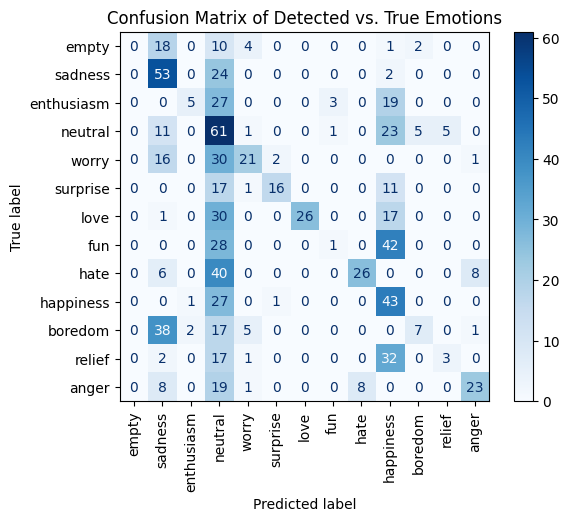

In [2]:
# Load the CSV file
filename = "processed_paragraph_results_llama-3.2-1b-instruct.txt.csv"
results_file = pd.read_csv(filename) 

# Define the ground truth and detected emotion columns
y_true = results_file["sentiment"]
y_pred = results_file["Detected Emotion"]

# List of emotions to keep the order consistent
emotions = ['empty', 'sadness', 'enthusiasm', 'neutral', 'worry', 'surprise', 
            'love', 'fun', 'hate', 'happiness', 'boredom', 'relief', 'anger']

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=emotions)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotions)
disp.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Confusion Matrix of Detected vs. True Emotions")
plt.show()

In [3]:
# Compute the balanced accuracy
balanced_acc = balanced_accuracy_score(y_true, y_pred)
print(f"Balanced Accuracy: {balanced_acc:.4f}")

# Compute the regular accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")

# Count the number of unique clusters (unique emotions predicted)
unique_clusters = results_file["Detected Emotion"].nunique()
print(f"Number of clusters (unique predicted emotions): {unique_clusters}")

Balanced Accuracy: 0.2939
Accuracy: 0.3272
Number of clusters (unique predicted emotions): 12


In [4]:

print(classification_report(results_file['sentiment'], results_file['Detected Emotion']))

              precision    recall  f1-score   support

       anger       0.70      0.39      0.50        59
     boredom       0.50      0.10      0.17        70
       empty       0.00      0.00      0.00        35
  enthusiasm       0.62      0.09      0.16        54
         fun       0.20      0.01      0.03        71
   happiness       0.23      0.60      0.33        72
        hate       0.76      0.33      0.46        80
        love       1.00      0.35      0.52        74
     neutral       0.18      0.57      0.27       107
      relief       0.38      0.05      0.10        55
     sadness       0.35      0.67      0.46        79
    surprise       0.84      0.36      0.50        45
       worry       0.62      0.30      0.40        70

    accuracy                           0.33       871
   macro avg       0.49      0.29      0.30       871
weighted avg       0.49      0.33      0.31       871



d:\Users\apnev\Documents\Thesis\llm_emotion_detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\apnev\Documents\Thesis\llm_emotion_detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\apnev\Documents\Thesis\llm_emotion_detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

In [5]:
# Define the mapping for combining emotions into new categories
emotion_mapping = {
    'sadness': 'Sadness',
    'worry': 'Sadness',
    'boredom': 'Sadness', 
    'fun': 'Joy',
    'enthusiasm': 'Joy',
    'happiness': 'Joy',
    'love': 'Love',
    'relief': 'Love',
    'anger': 'Hostility',
    'hate': 'Hostility',
    'surprise': 'Surprise',
    'neutral': 'Neutral',
    'empty': 'Neutral'
}

# Apply the mapping to both ground truth and detected emotion columns
results_file['Mapped Sentiment'] = results_file['sentiment'].map(emotion_mapping)
results_file['Mapped Detected Emotion'] = results_file['Detected Emotion'].map(emotion_mapping)

# Save to a new CSV file
results_file.to_csv(f"reduced_{filename}", index=False)

print(f"New file with reduced emotion classes saved as 'reduced_{filename}'.")

New file with reduced emotion classes saved as 'reduced_processed_paragraph_results_llama-3.2-1b-instruct.txt.csv'.


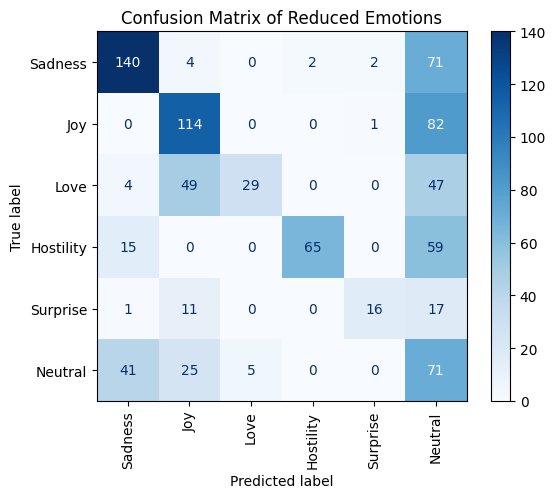

In [6]:
# Load the reduced CSV file
reduced_results_df = pd.read_csv(f"reduced_{filename}") 

# Define the ground truth and predicted emotion columns for reduced categories
y_true = reduced_results_df["Mapped Sentiment"]
y_pred = reduced_results_df["Mapped Detected Emotion"]

# List of reduced emotion categories to keep the order consistent
reduced_emotions = ['Sadness', 'Joy', 'Love', 'Hostility', 'Surprise', 'Neutral']

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=reduced_emotions)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=reduced_emotions)
disp.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Confusion Matrix of Reduced Emotions")
plt.show()

In [7]:
# Compute the balanced accuracy
balanced_acc = balanced_accuracy_score(y_true, y_pred)
print(f"Balanced Accuracy of 6 emotions: {balanced_acc:.4f}")

# Compute the regular accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy of 6 emotions: {acc:.4f}")

Balanced Accuracy of 6 emotions: 0.4610
Accuracy of 6 emotions: 0.4994


In [8]:

print(classification_report(reduced_results_df['Mapped Sentiment'], reduced_results_df['Mapped Detected Emotion']))

              precision    recall  f1-score   support

   Hostility       0.97      0.47      0.63       139
         Joy       0.56      0.58      0.57       197
        Love       0.85      0.22      0.36       129
     Neutral       0.20      0.50      0.29       142
     Sadness       0.70      0.64      0.67       219
    Surprise       0.84      0.36      0.50        45

    accuracy                           0.50       871
   macro avg       0.69      0.46      0.50       871
weighted avg       0.66      0.50      0.52       871



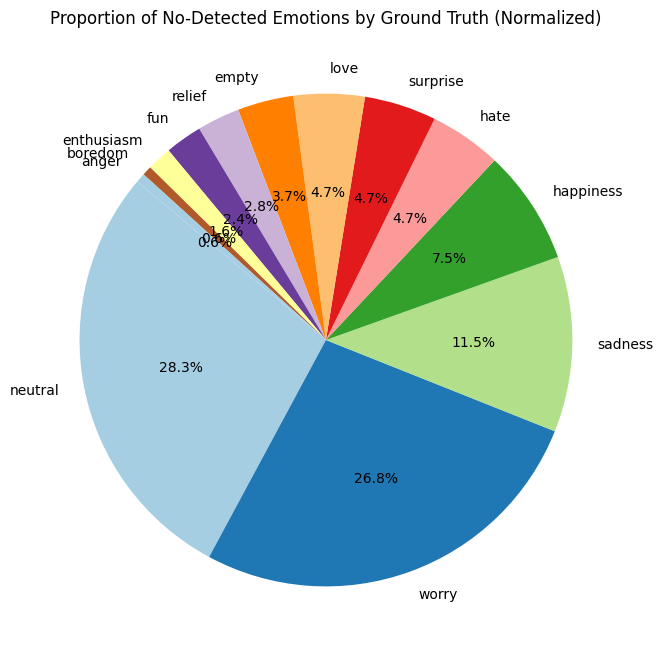

In [10]:
# Load the "no_emotion_detected.csv" file
no_emotion_df = pd.read_csv("no_emotion_detected.csv")

# Count the occurrences of each ground truth label in the "sentiment" column
emotion_counts = no_emotion_df['sentiment'].value_counts()

# Normalize the counts to get percentages
normalized_counts = (emotion_counts / emotion_counts.sum()) * 100

# Plot the normalized pie chart
plt.figure(figsize=(8, 8))
plt.pie(normalized_counts, labels=normalized_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title("Proportion of No-Detected Emotions by Ground Truth (Normalized)")
plt.show()


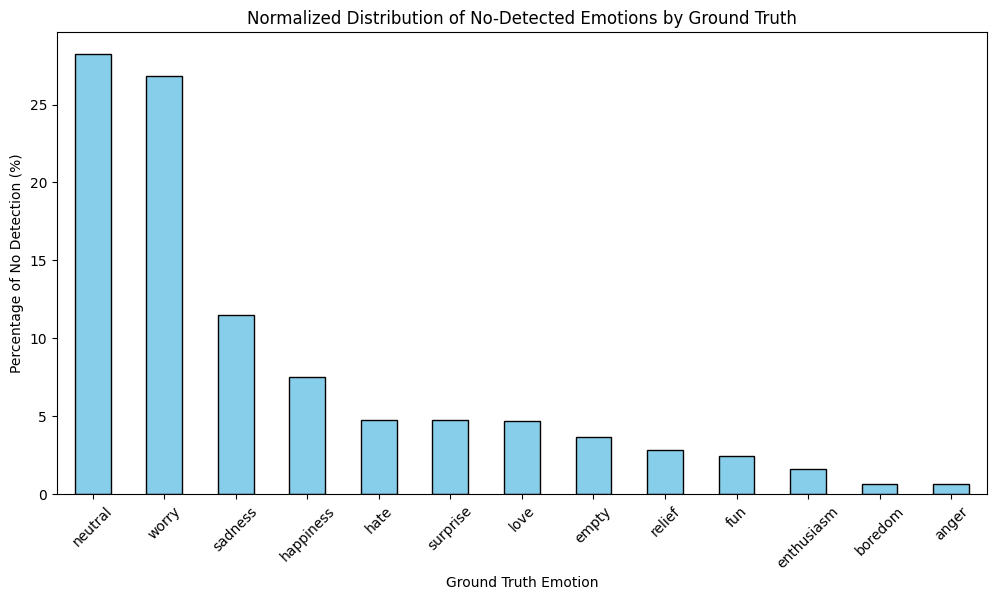

In [11]:
# Load the "no_emotion_detected.csv" file
no_emotion_df = pd.read_csv("no_emotion_detected.csv")

# Count the occurrences of each ground truth label in the "sentiment" column
emotion_counts = no_emotion_df['sentiment'].value_counts()

# Normalize the counts by dividing each by the total and multiplying by 100
normalized_counts = (emotion_counts / emotion_counts.sum()) * 100

# Plot the normalized bar chart
plt.figure(figsize=(12, 6))
normalized_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Normalized Distribution of No-Detected Emotions by Ground Truth")
plt.xlabel("Ground Truth Emotion")
plt.ylabel("Percentage of No Detection (%)")
plt.xticks(rotation=45)
plt.show()


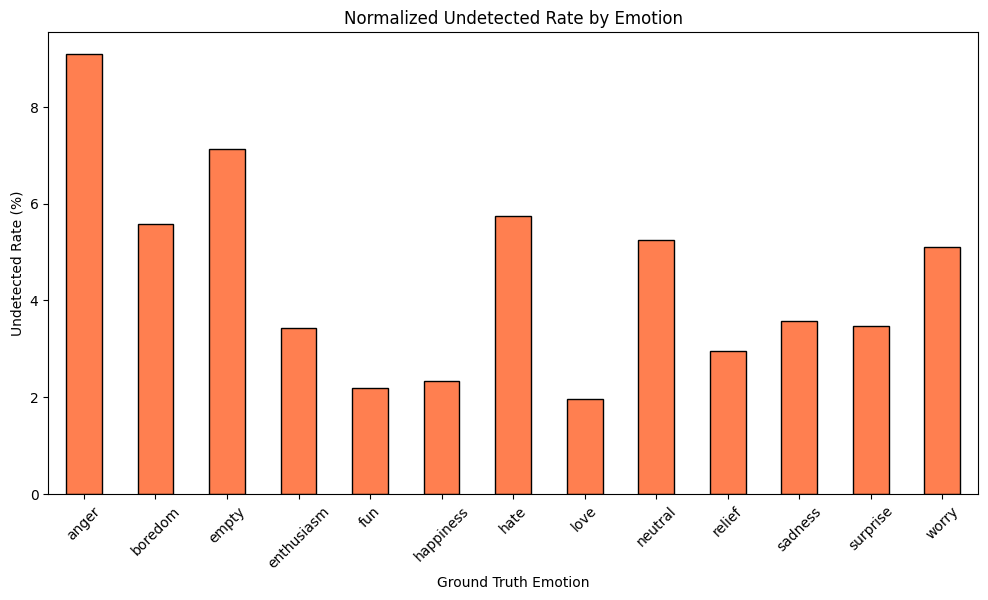

In [12]:
# Load the original dataset and the "no_emotion_detected.csv" file
original_df = pd.read_csv("tweet_emotions.csv")
no_emotion_df = pd.read_csv("no_emotion_detected.csv")

# Count occurrences of each emotion in the original dataset
original_counts = original_df['sentiment'].value_counts()

# Count occurrences of each emotion in the "no emotion detected" dataset
no_emotion_counts = no_emotion_df['sentiment'].value_counts()

# Normalize: divide the count of no-detection cases by the original count for each emotion
# Multiply by 100 to get a percentage (undetected rate)
undetected_rate = (no_emotion_counts / original_counts) * 100

# Fill NaN values with 0 (for emotions with no undetected cases)
undetected_rate = undetected_rate.fillna(0)

# Plot the normalized bar chart
plt.figure(figsize=(12, 6))
undetected_rate.plot(kind='bar', color='coral', edgecolor='black')
plt.title("Normalized Undetected Rate by Emotion")
plt.xlabel("Ground Truth Emotion")
plt.ylabel("Undetected Rate (%)")
plt.xticks(rotation=45)
plt.show()
